Name:  Shivam Jaywant Kakade

Project Guide: Gayatri Kamtekar 

Domain: Data Science AI/Ml

Link  : https://www.kaggle.com/code/shivamkakade22/diabetes-prediction-system-12345/edit

Project Name: Diabetes Prediction System

Business Understanding

Problem Statement:

The main problem we are addressing is predicting whether a patient is diabetic or not based on medical attributes such as glucose level, BMI, age, insulin level, blood pressure, and other health indicators.
Early detection of diabetes is very important because it helps prevent serious complications like kidney failure, heart disease, and vision problems.

In [97]:
# Basic Libraries
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - Model Selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# Sklearn - Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Sklearn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Sklearn - Evaluation
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score


Data Understanding

In [98]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [99]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [100]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


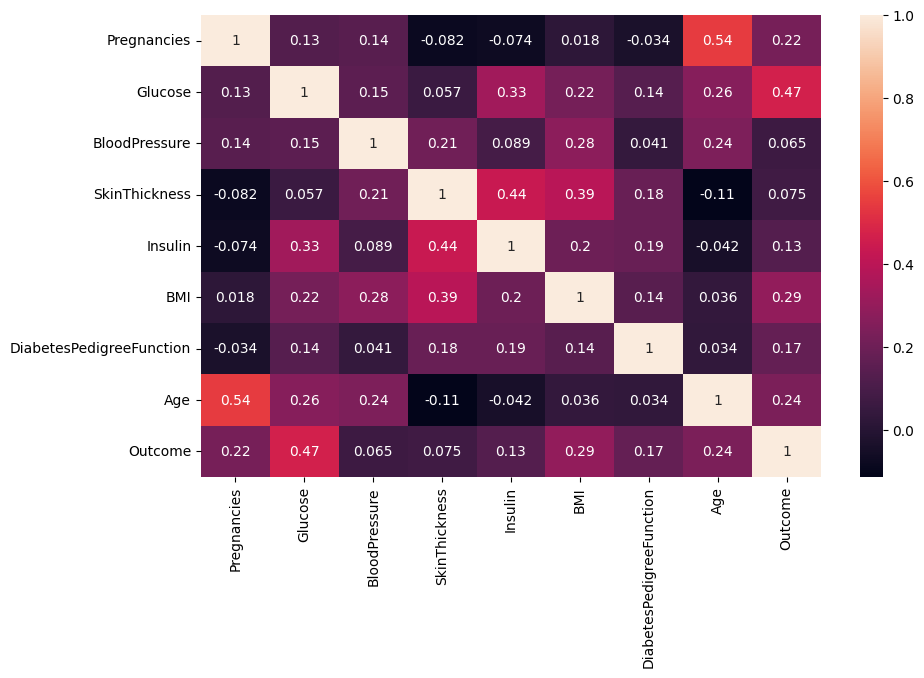

In [101]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()


Data Preparation

In [102]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols] = df[cols].replace(0, np.nan)

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
df[cols] = imputer.fit_transform(df[cols])


In [103]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']


Train-Test Split

In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Data Preprocessing

In [105]:
SimpleImputer(strategy='mean')


SimpleImputer()

In [106]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Exploratory Data Analysis (EDA)

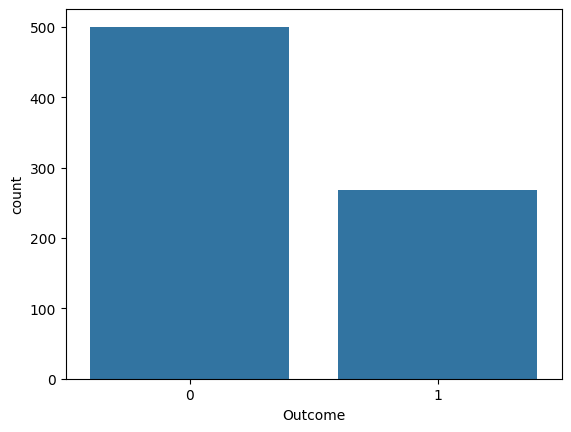

In [107]:
sns.countplot(x='Outcome', data=df)
plt.show()


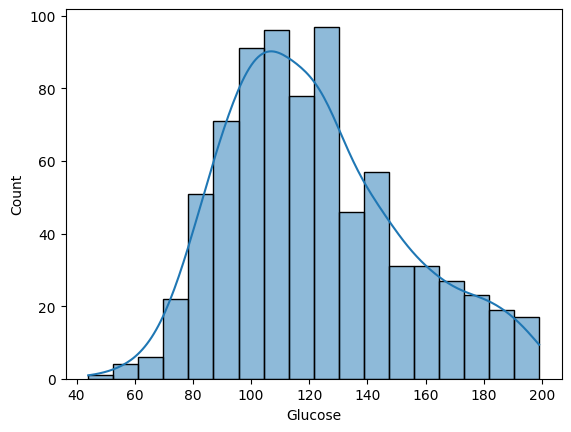

In [108]:
sns.histplot(df['Glucose'], kde=True)
plt.show()


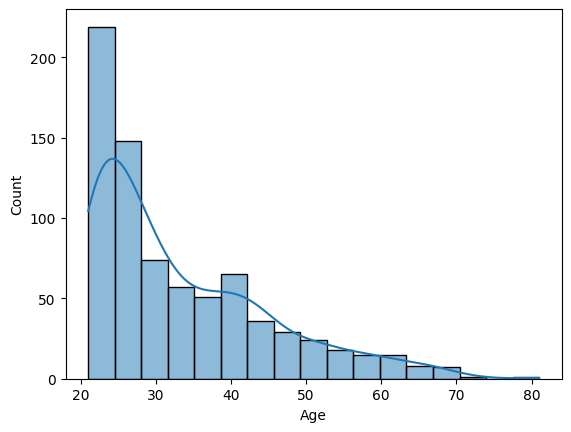

In [109]:
sns.histplot(df['Age'], kde=True)
plt.show()


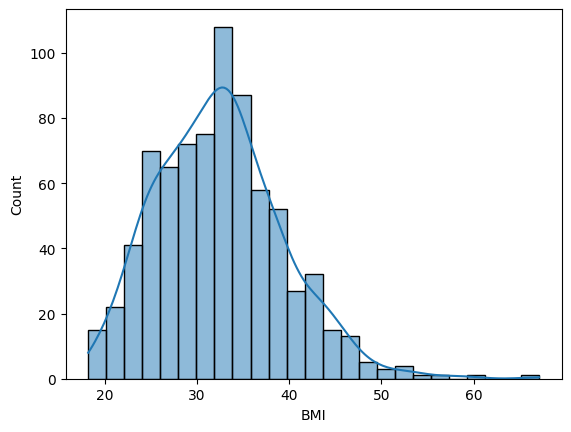

In [110]:
sns.histplot(df['BMI'], kde=True)
plt.show()


Model Selection

In [111]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)


In [112]:
from sklearn.model_selection import cross_val_score
cv_log = cross_val_score(log_model, X, y, cv=5)
print(cv_log.mean())


0.7708598590951532


In [113]:
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

cv_tree = cross_val_score(tree_model, X, y, cv=5)
print(cv_tree.mean())


0.7045751633986927


In [114]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

cv_rf = cross_val_score(rf_model, X, y, cv=5)
print(cv_rf.mean())


0.7591970121381886


Prediction

In [115]:
log_model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [116]:
y_pred = log_model.predict(X_test)


In [117]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[82 17]
 [21 34]]
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



In [118]:
# Create new patient dataframe
new_patient = pd.DataFrame(
    [[2,120,70,20,85,28.5,0.5,35]],
    columns=X.columns
)

# Scale input
new_patient_scaled = scaler.transform(new_patient)

# Predict class
prediction = log_model.predict(new_patient_scaled)

# Predict probability
probability = log_model.predict_proba(new_patient_scaled)

# Extract probability of being diabetic
diabetes_prob = probability[0][1] * 100

print("====================================")
print("      🩺 Diabetes Prediction Result")
print("====================================")

if prediction[0] == 1:
    print("Prediction        : Diabetic")
else:
    print("Prediction        : Not Diabetic")

print(f"Diabetes Probability : {diabetes_prob:.2f}%")

# Risk level classification
if diabetes_prob < 30:
    print("Risk Level        : Low Risk 🟢")
elif diabetes_prob < 70:
    print("Risk Level        : Medium Risk 🟡")
else:
    print("Risk Level        : High Risk 🔴")

print("====================================")


      🩺 Diabetes Prediction Result
Prediction        : Not Diabetic
Diabetes Probability : 21.15%
Risk Level        : Low Risk 🟢


Conclusion


The Diabetes Prediction System predicts diabetes risk using patient data with good accuracy.
It helps in early detection and preventive care, showing the usefulness of AI in healthcare.
With more data and tuning, the model can become even more reliable.
This system can support doctors and patients in making informed health decisions.
